### **1. Linear Regression**

#### 1.1 Linear Model

* Given an $n$-dimensional input: $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$
* A linear model has an $n$-dimensional weight vector and a scalar bias:
    $$\mathbf{w} = [w_1, w_2, \dots, w_n]^T, \quad b$$
* The output is a weighted sum of the inputs:
    $$y = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

    Vectorized version: $y = \langle\mathbf{w}, \mathbf{x}\rangle + b$

#### 1.2 Case Example: House Price 
##### Measuring Prediction Quality

* Compare the true value with the predicted value, for example, actual house sale prices versus estimated prices.
* Assume $y$ is the true value and $\hat{y}$ is the estimated value, we can compare them using:
    $$\ell(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$$

This is called the **squared loss**.

#### 1.3 Training Data

* Collect data points to determine parameter values (weights and bias), such as houses sold over the past 6 months.
* This is called **training data**.
* Generally, the more data, the better.
* Assume we have $n$ examples, denoted as:
    $$\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_n]^T, \quad \mathbf{y} = [y_1, y_2, \dots, y_n]^T$$

#### 1.4 Parameter Learning

* **Training Loss:**
    $$\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}, b) = \frac{1}{2n} \sum_{i=1}^{n} \left(y_i - \langle\mathbf{x}_i, \mathbf{w}\rangle - b\right)^2 = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\mathbf{w} - b\|^2$$

* **Learn parameters by minimizing the loss:**
    $$\mathbf{w}^*, b^* = \arg\min_{\mathbf{w}, b} \ell(\mathbf{X}, \mathbf{y}, \mathbf{w}, b)$$

#### 1.5 Linear Regression: Analytical Solution (Normal Equation)

##### 1.5.1 The Trick: Absorbing the Bias
To simplify the notation, we absorb the bias $b$ into the weight vector $\mathbf{w}$ and add a column of ones to the feature matrix $\mathbf{X}$:
$$\mathbf{X} \leftarrow [\mathbf{X}, \mathbf{1}], \quad \mathbf{w} \leftarrow \begin{bmatrix} \mathbf{w} \\ b \end{bmatrix}$$
This allows us to write the prediction simply as $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$.

##### 1.5.2 Loss Function (Mean Squared Error)
The loss function measures the average squared difference between the true labels $\mathbf{y}$ and predictions $\mathbf{X}\mathbf{w}$:
$$\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}) = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 = \frac{1}{2n} (\mathbf{y} - \mathbf{X}\mathbf{w})^T(\mathbf{y} - \mathbf{X}\mathbf{w})$$

##### 1.5.3 Optimization via Convexity
Since the MSE loss is a **convex function**, its global minimum occurs where the gradient (partial derivative) with respect to $\mathbf{w}$ is zero:
$$\frac{\partial}{\partial \mathbf{w}}\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}) = \frac{1}{n}(\mathbf{y} - \mathbf{X}\mathbf{w})^T\mathbf{X} = \mathbf{0}$$

**Recap:** $$\frac{\partial}{\partial \mathbf{w}}(\mathbf{w}^T\mathbf{A}\mathbf{w}) = 2\mathbf{w}^T\mathbf{A}$$

##### 1.5.4 Solving for $\mathbf{w}^*$
Setting the gradient to zero and solving for $\mathbf{w}$:
$$\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w}) = \mathbf{0}$$
$$\mathbf{X}^T\mathbf{y} - \mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{0}$$
$$\mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$$

Multiplying both sides by the inverse $(\mathbf{X}^T\mathbf{X})^{-1}$ yields the **Normal Equation**:
$$\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

#### **Summary: Linear Regression**

* Linear regression applies weights to $n$-dimensional inputs and adds a bias.
* It uses squared loss to measure the difference between predicted and true values.
* Linear regression has an analytical solution (closed-form solution).
* Linear regression can be viewed as a single-layer neural network.

### **2 Basic Optimization Algorithms**

#### 1. Gradient Descent
- **Initialization:** Pick an initial parameter value $\mathbf{w}_0$.
- **Iteration:** Repeat updating the parameters for $t = 1, 2, 3, \dots$
  $$\mathbf{w}_t = \mathbf{w}_{t-1} - \eta \frac{\partial \ell}{\partial \mathbf{w}_{t-1}}$$
- **Concept:** Moving along the gradient direction increases the value of the loss function, so we subtract the gradient to minimize the loss.
- **Learning Rate ($\eta$):** A hyperparameter that determines the step size of each update.

#### 2. Minibatch Stochastic Gradient Descent (SGD)
- **Motivation:** Computing the gradient over the entire training set is computationally too expensive. For a deep neural network model, a single update could take minutes to hours.
- **Approximation:** We can randomly sample $b$ examples $i_1, i_2, \dots, i_b$ to approximate the overall loss:
  $$\frac{1}{b} \sum_{i \in I_b} \ell(\mathbf{x}_i, y_i, \mathbf{w})$$
- **Batch Size ($b$):** Another critical hyperparameter representing the number of samples in each batch.

#### 3. Choosing Batch Size
- **Cannot be too small:** If the computational load per iteration is too small, it is not suitable for maximizing the utilization of computational resources through parallel processing.
- **Cannot be too large:** Significantly increases memory consumption. It may also lead to wasted computation (for example, if all samples happen to be identical or highly similar, redundant calculations don't provide extra gradient information).

#### 4. Summary
- **Optimization Strategy:** Gradient descent solves for parameters by continuously updating them along the negative gradient direction.
- **Default Algorithm:** Minibatch Stochastic Gradient Descent is the default solving algorithm used in deep learning.
- **Key Hyperparameters:** The two most important hyperparameters are the **Batch Size** and the **Learning Rate**.

#### **3 Linear Regression (Start From Scratch)**

In [10]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

#### Example:
Generate a synthetic dataset based on a linear model with noise. 
We use the linear model parameters $$\mathbf{w} = [2, -3.4]^\top$$ $$b = 4.2$$ and a noise term $\epsilon$ to generate the dataset and its labels:

$$\mathbf{y} = \mathbf{X}\mathbf{w} + b + \epsilon$$

In [11]:
def synthetic_daata(w,b,num_examples):
    """Generate y=wx+b+ε"""
    x=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(x,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return x,y.reshape((-1,1))

true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_daata(true_w,true_b,1000)

In [12]:
# Each row in features contains a two-dimensional data sample, and each row in labels contains a one-dimensional label value (a scalar)
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([ 1.4530, -1.0544]) 
label: tensor([10.6997])


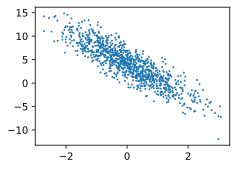

In [13]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),\
                labels.detach().numpy(),1);

In [14]:
# Define a data_iter function that takes the batch size, feature matrix, and label vector as inputs, and generates mini-batches of size batch_size
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    # These examples are read randomly with no particular order
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

batch_size=10

for x,y in data_iter(batch_size,features,labels):
    print(x,'\n',y)
    break

tensor([[ 1.3728,  1.8879],
        [-1.2094, -0.5592],
        [ 0.2877, -0.1880],
        [-1.0919, -2.1216],
        [ 1.3840,  0.0185],
        [-0.1726,  0.1249],
        [-0.4434, -0.7502],
        [ 0.3350, -0.2627],
        [ 0.2424, -0.6956],
        [ 1.4536,  0.4835]]) 
 tensor([[0.5213],
        [3.6944],
        [5.4210],
        [9.2275],
        [6.8909],
        [3.4294],
        [5.8715],
        [5.7509],
        [7.0553],
        [5.4649]])


In [17]:
# Training process
lr=0.03
num_epochs=3
net=linreg
loss=squared_loss

for epoch in range(num_epochs):
    for x, y in data_iter(batch_size,features,labels):
        l = loss(net(x, w, b), y)  # Mini-batch loss for x and y
        # Because l has shape (batch_size, 1) instead of being a scalar,
        # all elements in l are summed together to compute the gradients with respect to [w, b]
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # Update parameters using their gradients
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.038288
epoch 2, loss 0.000145
epoch 3, loss 0.000052
